## 1. Kurulum ve Bağımlılıklar

## ⚙️ Konfigürasyon — Sadece bu hücreyi değiştir!

Farklı bir dataset veya checkpoint için **yalnızca aşağıdaki hücreyi** güncelle. Geri kalan tüm hücreler buradan okur.

In [1]:
REPO_URL           = "https://github.com/Aliekinozcetin/DiffuVQA-Original.git"
BRANCH             = "pubmedbert"
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/DiffuVQA-PubMedBERT"
LOCAL_CLONE_PATH   = "/content/DiffuVQA-Original"

MODEL_NAME  = "pubmedbert"
MODEL_LABEL = "DiffuVQA-PubMedBERT"

DATASET          = "Kvasir_VQA"   # Kvasir_VQA | SLAKE | Med_VQA_2019
DATA_DIR         = "datasets"
IMAGEFOLDER_NAME = "Kvasir_VQA/imgs"   # config.json'daki image_dir ile aynı: datasets/Kvasir_VQA/imgs
DRIVE_IMAGE_DIR  = f"{DRIVE_PROJECT_PATH}/datasets/{IMAGEFOLDER_NAME}"
LOCAL_IMAGE_DIR  = f"{LOCAL_CLONE_PATH}/datasets/{IMAGEFOLDER_NAME}"

DATASET_IMG_PATHS = [
    f"/content/drive/MyDrive/datasets/{IMAGEFOLDER_NAME}",
    f"/content/drive/MyDrive/DiffuVQA-PubMedBERT/datasets/{IMAGEFOLDER_NAME}",
    f"/content/drive/Drive'ım/DiffuVQA-PubMedBERT/datasets/{IMAGEFOLDER_NAME}",
]

TRAIN_BATCH_SIZE  = 4    # Eğitim batch size (A100 40GB için güvenli)
SAMPLE_BATCH_SIZE = 64   # Sampling batch size (gradient yok, bellek baskısı düşük)
MICROBATCH        = 0    # 0 = microbatch devre dışı, batch_size ile aynı davranır
LR          = 1e-5

LEARNING_STEPS  = 500000
DIFFUSION_STEPS = 2500
SEQ_LEN         = 32
HIDDEN_DIM      = 768
SEED            = 102
SAVE_INTERVAL   = 25000
LOG_INTERVAL    = 1000
IMAGE_RESOLUTION = 384
NOISE_SCHEDULE   = "sqrt"
MODEL_TYPE       = "transformer-bert"
IMAGE_ENCODER    = "ViT-B/32"
USE_FP16         = False

SAMPLE_STEP  = 200   # DDIM adımı; 2500 = tam diffusion
SAMPLE_SEED2 = 105

CHECKPOINT_PATH    = f"{DRIVE_PROJECT_PATH}/checkpoints/{DATASET.lower()}/{MODEL_NAME}/lr{LR}"
SAMPLE_FOLDER      = f"{DRIVE_PROJECT_PATH}/samples/{DATASET.lower()}/{MODEL_NAME}"
OUTPUT_CSV         = f"./reports/{MODEL_NAME}_{DATASET.lower()}_evaluation_results.csv"
DRIVE_RESULTS_PATH = f"{DRIVE_PROJECT_PATH}/results/"

# Sıfırdan eğitim: boş bırak. Devam: tam dosya yolunu gir.
RESUME_CHECKPOINT = "/content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05/ema_0.9999_100000.pt"

print(f"Repo      : {REPO_URL}  →  branch: {BRANCH}")
print(f"Model     : {MODEL_NAME} | Dataset: {DATASET}")
print(f"TrainBatch: {TRAIN_BATCH_SIZE} | SampleBatch: {SAMPLE_BATCH_SIZE} | LR: {LR} | Steps: {LEARNING_STEPS}")
print(f"DiffSteps: {DIFFUSION_STEPS} | SeqLen: {SEQ_LEN} | SaveInterval: {SAVE_INTERVAL}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Resume    : {RESUME_CHECKPOINT or 'None (sıfırdan eğitim)'}")

Repo      : https://github.com/Aliekinozcetin/DiffuVQA-Original.git  →  branch: pubmedbert
Model     : pubmedbert | Dataset: Kvasir_VQA
TrainBatch: 4 | SampleBatch: 64 | LR: 1e-05 | Steps: 500000
DiffSteps: 2500 | SeqLen: 32 | SaveInterval: 25000
Checkpoint: /content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05
Resume    : /content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05/ema_0.9999_100000.pt


### GPU Kontrolü

In [2]:
!nvidia-smi

Fri May 29 08:51:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Google Drive Bağlantısı

Checkpoint'ler ve dataset Drive'da kalıcı olarak saklanır.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Repo Clone + Drive Sync

GitHub'dan taze klon çeker, kod dosyalarını `DiffuVQA-Original` klasörüne kopyalar (`datasets/`, `checkpoints/` atlanır).

In [4]:
import os
import shutil

os.chdir("/content")

if os.path.exists(LOCAL_CLONE_PATH):
    print(f"Eski geçici klasör siliniyor: {LOCAL_CLONE_PATH}")
    shutil.rmtree(LOCAL_CLONE_PATH)

print("GitHub'dan taze kopya çekiliyor...")
!git clone -b {BRANCH} --single-branch {REPO_URL} {LOCAL_CLONE_PATH}

print(f"\nSon 3 commit:")
!git -C {LOCAL_CLONE_PATH} log -3 --oneline

print(f"\nDrive'daki kod dosyaları güncelleniyor: {DRIVE_PROJECT_PATH}")
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

SKIP_DIRS = {"datasets", "checkpoints", "samples", "outputs", "reports", "results", ".git", "__pycache__"}
for item in os.listdir(LOCAL_CLONE_PATH):
    if item in SKIP_DIRS:
        continue
    src_path = os.path.join(LOCAL_CLONE_PATH, item)
    dst_path = os.path.join(DRIVE_PROJECT_PATH, item)
    if os.path.isdir(src_path):
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
    else:
        shutil.copy2(src_path, dst_path)

os.chdir(DRIVE_PROJECT_PATH)
print(f"\nÇalışma dizini: {os.getcwd()}")

GitHub'dan taze kopya çekiliyor...
Cloning into '/content/DiffuVQA-Original'...
remote: Enumerating objects: 504, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 504 (delta 142), reused 139 (delta 130), pack-reused 325 (from 1)
Receiving objects: 100% (504/504), 3.15 MiB | 35.02 MiB/s, done.
Resolving deltas: 100% (258/258), done.

Son 3 commit:
fed7bd3 (HEAD -> pubmedbert, origin/pubmedbert) Remove unused imports and duplicate imports
8597922 Fix remaining BERT references missed in pubmedbert branch
325f1e3 Replace all bert-base-uncased references with PubMedBERT

Drive'daki kod dosyaları güncelleniyor: /content/drive/MyDrive/DiffuVQA-PubMedBERT

Çalışma dizini: /content/drive/MyDrive/DiffuVQA-PubMedBERT


### Mevcut Drive Reposunu Güncelle

Clone yerine Drive'daki mevcut repoyu `git reset --hard` ile güncel branch'e çeker. Clone hücresine alternatif.

In [5]:
import os
if os.path.exists(DRIVE_PROJECT_PATH):
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"Çalışma dizini: {os.getcwd()}")
    !git fetch origin {BRANCH}
    !git reset --hard origin/{BRANCH}
    !git log -3 --oneline
else:
    print("Drive'da proje klasörü bulunamadı. Önce clone hücresini çalıştır.")

Çalışma dizini: /content/drive/MyDrive/DiffuVQA-PubMedBERT
From https://github.com/Aliekinozcetin/DiffuVQA-Original
 * branch            pubmedbert -> FETCH_HEAD
Updating files: 100% (87/87), done.
HEAD is now at fed7bd3 Remove unused imports and duplicate imports
fed7bd3 (HEAD -> pubmedbert, origin/pubmedbert) Remove unused imports and duplicate imports
8597922 Fix remaining BERT references missed in pubmedbert branch
325f1e3 Replace all bert-base-uncased references with PubMedBERT


### Kvasir-VQA Datasetini İndir

Drive'da zaten varsa atlar; yoksa Zenodo'dan (~400 MB) indirir ve Drive'a kalıcı olarak kaydeder.

In [6]:
import os, json, random

DRIVE_DATASET_ROOT = f"{DRIVE_PROJECT_PATH}/datasets/Kvasir_VQA"
DRIVE_IMGS_DIR     = f"{DRIVE_DATASET_ROOT}/imgs"
DRIVE_JSONL_TRAIN  = f"{DRIVE_DATASET_ROOT}/train.jsonl"
DRIVE_HF_CACHE     = f"{DRIVE_PROJECT_PATH}/hf_cache"

# ── Zaten hazır mı? ──────────────────────────────────────────────────────────
if os.path.isdir(DRIVE_IMGS_DIR) and os.path.isfile(DRIVE_JSONL_TRAIN):
    img_count = sum(1 for f in os.listdir(DRIVE_IMGS_DIR)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    print(f"✓ Dataset zaten Drive'da mevcut: {DRIVE_DATASET_ROOT}")
    print(f"  Görüntü sayısı: {img_count} | train.jsonl: OK")
    print("  İndirme atlandı.")

# ── İndir + Drive'a kaydet ───────────────────────────────────────────────────
else:
    print("Dataset bulunamadı. HuggingFace'den indiriliyor (SimulaMet-HOST/Kvasir-VQA)...")
    print("İlk seferinde ~15-20 dk sürebilir; sonraki session'larda anında geçer.\n")

    # HF_ENDPOINT hf-mirror bu dataset'i servis etmiyor → geçici kaldır
    _endpoint = os.environ.pop("HF_ENDPOINT", None)

    # HF cache'ini Drive'a yönlendir — parquet'lar burada kalıcı olarak durur
    os.makedirs(DRIVE_HF_CACHE, exist_ok=True)
    os.environ["HF_DATASETS_CACHE"] = DRIVE_HF_CACHE
    os.environ["HF_HOME"]           = DRIVE_HF_CACHE

    !pip install -q datasets pillow pandas

    from datasets import load_dataset
    from PIL import Image as PILImage
    import pandas as pd

    os.makedirs(DRIVE_IMGS_DIR, exist_ok=True)

    print("Parquet dosyaları Drive cache'e indiriliyor (~1.5 GB)...")
    ds = load_dataset("SimulaMet-HOST/Kvasir-VQA",
                      cache_dir=DRIVE_HF_CACHE,
                      trust_remote_code=True)
    raw = ds["raw"]   # tek split: 'raw', 58849 soru, 6500 benzersiz görüntü
    print(f"Toplam soru: {len(raw)} | Kolonlar: {raw.column_names}")

    # ── Görüntüleri kaydet (img_id bazında, tekrarsız) ───────────────────────
    print("\nGörüntüler kaydediliyor (6500 benzersiz)...")
    img_id_to_idx = {}
    for i, row in enumerate(raw):
        iid = row["img_id"]
        if iid not in img_id_to_idx:
            img_id_to_idx[iid] = i
        if len(img_id_to_idx) % 500 == 0 and i == img_id_to_idx[iid]:
            print(f"  {len(img_id_to_idx)} benzersiz görüntü işlendi...")

    saved = 0
    for img_id, idx in img_id_to_idx.items():
        img_path = os.path.join(DRIVE_IMGS_DIR, f"{img_id}.jpg")
        if not os.path.exists(img_path):
            pil_img = raw[idx]["image"]
            if not isinstance(pil_img, PILImage.Image):
                pil_img = PILImage.fromarray(pil_img)
            pil_img.convert("RGB").save(img_path, "JPEG", quality=95)
        saved += 1
        if saved % 500 == 0:
            print(f"  {saved}/{len(img_id_to_idx)} görüntü kaydedildi...")

    print(f"✓ {saved} görüntü kaydedildi → {DRIVE_IMGS_DIR}")

    # ── Tüm soruları JSONL satırlarına çevir ─────────────────────────────────
    # image_name: sadece dosya adı (img_id.jpg) — vqa_datasets.py image_dir ile birleştirir
    print("\nSoru-cevap satırları oluşturuluyor...")
    all_rows = []
    for row in raw:
        all_rows.append({
            "image_name": f"{row['img_id']}.jpg",
            "question":   row["question"],
            "answer":     row["answer"],
        })

    # ── Train / valid / test böl (80 / 10 / 10, tekrarlanabilir) ─────────────
    random.seed(42)
    random.shuffle(all_rows)
    n = len(all_rows)
    n_train = int(n * 0.80)
    n_valid = int(n * 0.10)
    splits = {
        "train": all_rows[:n_train],
        "valid": all_rows[n_train:n_train + n_valid],
        "test":  all_rows[n_train + n_valid:],
    }

    for split_name, rows in splits.items():
        jsonl_path = os.path.join(DRIVE_DATASET_ROOT, f"{split_name}.jsonl")
        with open(jsonl_path, "w", encoding="utf-8") as fout:
            for r in rows:
                fout.write(json.dumps(r) + "\n")
        print(f"  ✓ {split_name}.jsonl → {len(rows)} satır")

    # HF_ENDPOINT geri al
    if _endpoint:
        os.environ["HF_ENDPOINT"] = _endpoint

    print(f"\n✓ Tamamlandı!")
    print(f"  imgs + JSONL : {DRIVE_DATASET_ROOT}")
    print(f"  HF cache     : {DRIVE_HF_CACHE}  (parquet'lar burada, bir daha indirilmez)")
    !ls -lh {DRIVE_DATASET_ROOT}

✓ Dataset zaten Drive'da mevcut: /content/drive/MyDrive/DiffuVQA-PubMedBERT/datasets/Kvasir_VQA
  Görüntü sayısı: 6500 | train.jsonl: OK
  İndirme atlandı.


### Dataset Görüntülerini Kopyala

Drive'daki veya aday listesindeki görüntüleri Colab runtime'ına kopyalar. `ACTIVE_IMAGE_DIR` bu hücrede belirlenir.

In [7]:
import os, json

# Drive'daki JSONL'lerde image_name "imgs/xxx.jpg" formatındaysa "xxx.jpg"'e düzelt.
# vqa_datasets.py zaten image_dir/image_name şeklinde birleştiriyor;
# "imgs/" prefix burada olursa sonuç .../imgs/imgs/xxx.jpg → FileNotFoundError.
DRIVE_DATASET_ROOT = f"{DRIVE_PROJECT_PATH}/datasets/Kvasir_VQA"

for split in ("train", "valid", "test"):
    jsonl_path = os.path.join(DRIVE_DATASET_ROOT, f"{split}.jsonl")
    if not os.path.exists(jsonl_path):
        print(f"  {split}.jsonl bulunamadı, atlanıyor.")
        continue
    rows, fixed = [], 0
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            name = row.get("image_name", "")
            if name.startswith("imgs/"):
                row["image_name"] = name[len("imgs/"):]
                fixed += 1
            rows.append(row)
    if fixed > 0:
        with open(jsonl_path, "w", encoding="utf-8") as f:
            for row in rows:
                f.write(json.dumps(row) + "\n")
        print(f"✓ {split}.jsonl: {fixed} satırda 'imgs/' prefix kaldırıldı.")
    else:
        print(f"  {split}.jsonl: düzeltme gerekmedi.")

  train.jsonl: düzeltme gerekmedi.
  valid.jsonl: düzeltme gerekmedi.
  test.jsonl: düzeltme gerekmedi.


In [8]:
import os
import shutil
from tqdm.auto import tqdm

def resolve_dataset_image_source(candidate_paths):
    seen = set()
    for path in candidate_paths:
        if not path or not isinstance(path, str):
            continue
        norm = os.path.normpath(path)
        if norm in seen:
            continue
        seen.add(norm)
        if os.path.exists(path) and len(os.listdir(path)) > 0:
            return path
    return None

# Colab runtime'ındaki hedef klasör (eğitim buradan okur)
dataset_local_imgs = os.path.join(LOCAL_CLONE_PATH, DATA_DIR, IMAGEFOLDER_NAME)

source_candidates = [
    LOCAL_IMAGE_DIR,    # runtime'da zaten var mı
    DRIVE_IMAGE_DIR,    # Drive/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
    *DATASET_IMG_PATHS,
]
source_image_path = resolve_dataset_image_source(source_candidates)

if source_image_path:
    src_abs = os.path.abspath(source_image_path)
    dst_abs = os.path.abspath(dataset_local_imgs)

    if src_abs == dst_abs:
        print("Kaynak zaten local runtime path'te; kopyalama atlandı.")
        ACTIVE_IMAGE_DIR = dataset_local_imgs
    else:
        os.makedirs(dataset_local_imgs, exist_ok=True)
        files_to_copy = []
        for root, _, files in os.walk(source_image_path):
            for file_name in files:
                src_file = os.path.join(root, file_name)
                rel_path = os.path.relpath(src_file, source_image_path)
                dst_file = os.path.join(dataset_local_imgs, rel_path)
                files_to_copy.append((src_file, dst_file))

        for src_file, dst_file in tqdm(files_to_copy, desc="Copying dataset images", unit="file"):
            os.makedirs(os.path.dirname(dst_file), exist_ok=True)
            shutil.copy2(src_file, dst_file)

        print(f"Kopyalandı: {len(files_to_copy)} dosya → {dataset_local_imgs}")
        ACTIVE_IMAGE_DIR = dataset_local_imgs
else:
    # Runtime'a kopyalanamadıysa doğrudan Drive'dan oku
    if os.path.exists(DRIVE_IMAGE_DIR) and len(os.listdir(DRIVE_IMAGE_DIR)) > 0:
        print(f"Runtime kopyası oluşturulamadı; Drive'dan direkt okunacak: {DRIVE_IMAGE_DIR}")
        ACTIVE_IMAGE_DIR = DRIVE_IMAGE_DIR
    else:
        print("UYARI: Görüntü kaynağı bulunamadı. Önce dataset indirme hücresini çalıştırın.")
        ACTIVE_IMAGE_DIR = dataset_local_imgs

print(f"ACTIVE_IMAGE_DIR: {ACTIVE_IMAGE_DIR}")
img_count = sum(1 for f in os.listdir(ACTIVE_IMAGE_DIR)
                if f.lower().endswith(('.jpg','.jpeg','.png'))) if os.path.exists(ACTIVE_IMAGE_DIR) else 0
print(f"Görüntü sayısı  : {img_count}")

Copying dataset images:   0%|          | 0/6500 [00:00<?, ?file/s]

Kopyalandı: 6500 dosya → /content/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
ACTIVE_IMAGE_DIR: /content/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
Görüntü sayısı  : 6500


### Dataset Doğrulama

JSONL dosyalarının ve görüntü klasörünün doğru yerde olduğunu kontrol eder.

In [9]:
import os

JSONL_DIR = os.path.join(DRIVE_PROJECT_PATH, "datasets", "Kvasir_VQA")

print("Dataset klasörü:")
!ls -lh {JSONL_DIR}/ 2>/dev/null || echo "  Klasör bulunamadı: {JSONL_DIR}"

print("\nJSONL dosyaları:")
!ls -lh {JSONL_DIR}/*.jsonl 2>/dev/null || echo "  JSONL bulunamadı"

print(f"\nActive image dir: {ACTIVE_IMAGE_DIR}")
if os.path.exists(ACTIVE_IMAGE_DIR):
    imgs = sorted(os.listdir(ACTIVE_IMAGE_DIR))
    print(f"İlk 5 dosya ({len(imgs)} toplam):")
    for i, name in enumerate(imgs[:5], 1):
        print(f"  {i}. {name}")
else:
    print("  Active image dir bulunamadı.")

print("\nTrain set örneği:")
train_jsonl = os.path.join(JSONL_DIR, "train.jsonl")
!head -n 1 {train_jsonl} 2>/dev/null || echo "  train.jsonl bulunamadı"

Dataset klasörü:
total 7.3M
drwx------ 2 root root 4.0K May 29 00:11 imgs
-rw------- 1 root root 742K May 29 00:27 test.jsonl
-rw------- 1 root root 5.8M May 29 00:27 train.jsonl
-rw------- 1 root root 739K May 29 00:27 valid.jsonl

JSONL dosyaları:
-rw------- 1 root root 742K May 29 00:27 /content/drive/MyDrive/DiffuVQA-PubMedBERT/datasets/Kvasir_VQA/test.jsonl
-rw------- 1 root root 5.8M May 29 00:27 /content/drive/MyDrive/DiffuVQA-PubMedBERT/datasets/Kvasir_VQA/train.jsonl
-rw------- 1 root root 739K May 29 00:27 /content/drive/MyDrive/DiffuVQA-PubMedBERT/datasets/Kvasir_VQA/valid.jsonl

Active image dir: /content/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
İlk 5 dosya (6500 toplam):
  1. cl8k2u1pm1dw7083203g1b7yv.jpg
  2. cl8k2u1pm1dwb08325rls8okr.jpg
  3. cl8k2u1pn1dwf08320ke7bzr0.jpg
  4. cl8k2u1pn1dwj0832bf4714ye.jpg
  5. cl8k2u1pn1dwn083249fm9awa.jpg

Train set örneği:
{"image_name": "clb0kvxv990b8074yct0y4znb.jpg", "question": "Are there any instruments in the image? Check all 

### Görüntü Önizleme

Rastgele 5 dataset görüntüsünü gösterir. Kopyalama başarılıysa burada görüntüler çıkmalı.

6500 görüntü bulundu.


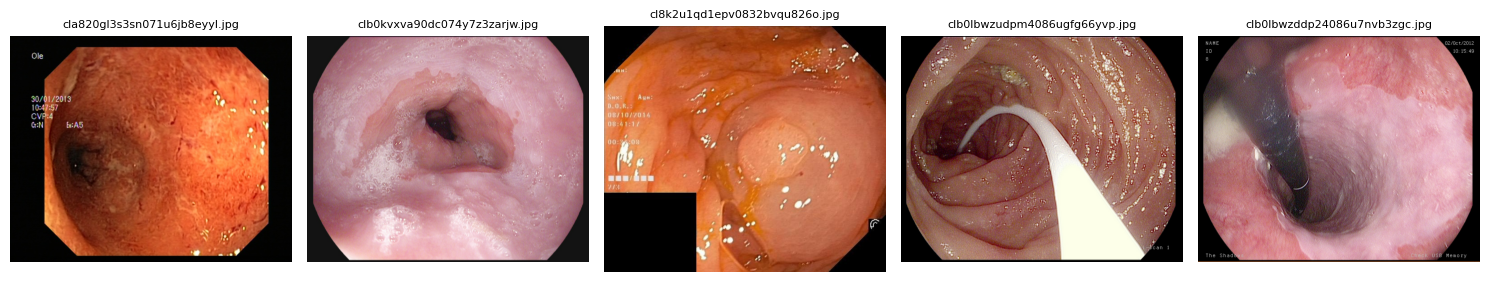

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

image_extensions = (".png", ".jpg", ".jpeg", ".gif", ".bmp", ".tiff")
all_image_files = []
for root, _, files in os.walk(ACTIVE_IMAGE_DIR):
    for file in files:
        if file.lower().endswith(image_extensions):
            all_image_files.append(os.path.join(root, file))

if not all_image_files:
    print(f"Görüntü bulunamadı: {ACTIVE_IMAGE_DIR}")
else:
    print(f"{len(all_image_files)} görüntü bulundu.")
    num_examples = min(5, len(all_image_files))
    selected_images = random.sample(all_image_files, num_examples)

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(selected_images):
        try:
            img = Image.open(img_path)
            plt.subplot(1, num_examples, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path), fontsize=8)
            plt.axis("off")
        except Exception as e:
            print(f"Görüntü yüklenemedi {img_path}: {e}")
    plt.tight_layout()
    plt.show()

### Bağımlılıkları Kur

In [11]:
!pip install --upgrade pip -q
!pip install -r requirements_colab.txt -q
!pip install pandas openpyxl bert-score scikit-learn -q
!python -m spacy download en_core_web_sm -q
print("Kurulum tamamlandı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Kurulum tamamlandı.


### Python Import'ları

In [12]:
import os
import sys
import json
import torch
import shutil
import pandas as pd
import numpy as np
from datetime import datetime
from collections import defaultdict
import glob

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB


## 2. Model Eğitimi

### PubMedBERT Ağırlıklarını Cache'e Al

HF mirror PubMedBERT'i servis etmediğinden `HF_ENDPOINT` geçici kaldırılır, ağırlıklar indirilir, sonra geri eklenir.

In [13]:
import os
from transformers import AutoModel, AutoTokenizer

# HF_ENDPOINT hf-mirror PubMedBERT ağırlıklarını servis etmiyor; geçici olarak kaldırılıyor
_endpoint = os.environ.pop("HF_ENDPOINT", None)
AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
AutoModel.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext")
if _endpoint:
    os.environ["HF_ENDPOINT"] = _endpoint
print("PubMedBERT cache'e alındı.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PubMedBERT cache'e alındı.


### Eğitimi Başlat

`RESUME_CHECKPOINT` set ise kaldığı yerden devam eder. Checkpoint'ler `CHECKPOINT_PATH`'e her `SAVE_INTERVAL` adımda kaydedilir.

En son checkpoint otomatik bulunur; sıfırdan başlamak istersen aşağıdaki hücreyi atlayıp `RESUME_CHECKPOINT = ""` bırak.

In [15]:
import os, re
os.chdir(DRIVE_PROJECT_PATH)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

DATA_DIR_ABS  = os.path.join(DRIVE_PROJECT_PATH, "datasets", "Kvasir_VQA")

# ACTIVE_IMAGE_DIR doğrula: session yeniden başlamışsa local /content/ klasörü yok → Drive'a fallback
_active = globals().get("ACTIVE_IMAGE_DIR", "")
if not _active or not os.path.exists(_active) or len(os.listdir(_active)) == 0:
    print(f"UYARI: ACTIVE_IMAGE_DIR erişilebilir değil ({_active!r}), Drive fallback kullanılıyor.")
    _active = DRIVE_IMAGE_DIR
IMAGE_DIR_ABS = _active
print(f"IMAGE_DIR_ABS: {IMAGE_DIR_ABS}")

# Kaçıncı adımdan devam edileceğini checkpoint adından çıkar
resume_step = 0
if RESUME_CHECKPOINT:
    m = re.search(r'(\d{6})', os.path.basename(RESUME_CHECKPOINT))
    if m:
        resume_step = int(m.group(1))
    print(f"Devam: {RESUME_CHECKPOINT}  (adım {resume_step} → {LEARNING_STEPS})")
else:
    print(f"Sıfırdan eğitim (0 → {LEARNING_STEPS} adım)")

resume_flag = f"--resume_checkpoint {RESUME_CHECKPOINT}" if RESUME_CHECKPOINT else ""

!python train.py \
    --checkpoint_path {CHECKPOINT_PATH} \
    --dataset {DATASET} \
    --data_dir {DATA_DIR_ABS} \
    --image_dir {IMAGE_DIR_ABS} \
    --batch_size {TRAIN_BATCH_SIZE} \
    --lr {LR} \
    --diffusion_steps {DIFFUSION_STEPS} \
    --seq_len {SEQ_LEN} \
    --hidden_dim {HIDDEN_DIM} \
    --learning_steps {LEARNING_STEPS} \
    --save_interval {SAVE_INTERVAL} \
    --log_interval {LOG_INTERVAL} \
    --eval_interval 500 \
    --noise_schedule {NOISE_SCHEDULE} \
    --model {MODEL_TYPE} \
    --image_resolution {IMAGE_RESOLUTION} \
    --seed {SEED} \
    --use_fp16 {USE_FP16} \
    {resume_flag}


IMAGE_DIR_ABS: /content/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
Devam: /content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05/ema_0.9999_100000.pt  (adım 100000 → 500000)
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/trace_rules.py", line 3894, in <module>
    add(_name)
  File "/usr/local/lib/python3.12/dist-packages/torch/_dynamo/trace_rules.py", line 3686, in add
    module_spec = find_spec(import_name)
                  ^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib.util>", line 100, in find_spec
  File "<frozen importlib._bootstrap>", line 1262, in _find_spec
  File "<frozen importlib._bootstrap_externa

## 3. Model Örnekleme (Inference)

### Sampling — Test Seti Üzerinde Cevap Üret

En son checkpoint ile `sample_vqa_GPU.py` çalıştırır. `SAMPLE_STEP=200` DDIM ile 2500 adım ~12x hızlanır. Çıktı `SAMPLE_FOLDER`'a `.jsonl` olarak kaydedilir.

In [16]:
import glob
import os
os.chdir(DRIVE_PROJECT_PATH)
os.makedirs(SAMPLE_FOLDER, exist_ok=True)

DATA_DIR_ABS  = os.path.join(DRIVE_PROJECT_PATH, "datasets", "Kvasir_VQA")

# ACTIVE_IMAGE_DIR doğrula: session yeniden başlamışsa local /content/ klasörü yok → Drive'a fallback
_active = globals().get("ACTIVE_IMAGE_DIR", "")
if not _active or not os.path.exists(_active) or len(os.listdir(_active)) == 0:
    print(f"UYARI: ACTIVE_IMAGE_DIR erişilebilir değil ({_active!r}), Drive fallback kullanılıyor.")
    _active = DRIVE_IMAGE_DIR
IMAGE_DIR_ABS = _active
print(f"IMAGE_DIR_ABS: {IMAGE_DIR_ABS}")

checkpoint_files = sorted(glob.glob(f"{CHECKPOINT_PATH}/ema_*.pt"))
if checkpoint_files:
    checkpoint_file = checkpoint_files[-1]
    print(f"Checkpoint: {checkpoint_file}")
else:
    print("Checkpoint bulunamadı. Önce eğitimi tamamlayın.")
    checkpoint_file = None

if checkpoint_file:
    !python sample_vqa_GPU.py \
        --model_path {checkpoint_file} \
        --step {SAMPLE_STEP} \
        --batch_size {SAMPLE_BATCH_SIZE} \
        --seed2 {SAMPLE_SEED2} \
        --split test \
        --out_dir {SAMPLE_FOLDER} \
        --clamp_step 0 \
        --data_dir {DATA_DIR_ABS} \
        --image_dir {IMAGE_DIR_ABS}

    !ls -lh {SAMPLE_FOLDER}/**/*.jsonl 2>/dev/null || ls -lh {SAMPLE_FOLDER}/*.jsonl 2>/dev/null | tail -5


IMAGE_DIR_ABS: /content/DiffuVQA-Original/datasets/Kvasir_VQA/imgs
Checkpoint: /content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05/ema_0.9999_150000.pt
Logging to /tmp/openai-2026-05-29-11-16-52-794880
/content/drive/MyDrive/DiffuVQA-PubMedBERT/checkpoints/kvasir_vqa/pubmedbert/lr1e-05/training_args.json
### Creating model and diffusion...
initializing from pretrained bert...
BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "tie_word_embeddings": true,
  "transformers_version": "5

## 4. Model Değerlendirme ve CSV Export

### Hızlı Eval — eval_DiffuVQA.py

Son checkpoint'in sample dosyasını bulur, ilk 5 örneği gösterir ve `eval_DiffuVQA.py` ile BLEU/ROUGE/METEOR/BERTScore/CIDEr hesaplar.

In [ ]:
import glob
import json
import os
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

os.chdir(DRIVE_PROJECT_PATH)

all_jsonl = sorted(
    glob.glob(f"{SAMPLE_FOLDER}/**/*.jsonl", recursive=True) +
    glob.glob(f"{SAMPLE_FOLDER}/*.jsonl")
)

if all_jsonl:
    sample_path = all_jsonl[-1]
    sample_folder = os.path.dirname(sample_path)

    print(f"Değerlendirilecek dosya: {sample_path}")
    print(f"Değerlendirilecek klasör: {sample_folder}")

    with open(sample_path, "r", encoding="utf-8") as f:
        rows = [json.loads(l) for l in f][:5]

    print("\nİlk 5 örnek:")
    for i, r in enumerate(rows):
        gen = r.get("generate_answer", "")
        ref = r.get("reference_answer", "")
        match = "AYNI (leakage?)" if gen.strip() == ref.strip() else "farklı"
        print(f"  [{i+1}] {match} | ref: '{ref}' | gen: '{gen}'")

    !python eval_DiffuVQA.py --folder "{sample_folder}"
else:
    print(f"Sample dosyası bulunamadı: {SAMPLE_FOLDER}")
    print("Önce Bölüm 3'ü çalıştırın.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Değerlendirilecek dosya: /content/drive/MyDrive/DiffuVQA-PubMedBERT/samples/kvasir_vqa/pubmedbert/lr1e-05/ema_0.9999_150000.jsonl
Değerlendirilecek klasör: /content/drive/MyDrive/DiffuVQA-PubMedBERT/samples/kvasir_vqa/pubmedbert/lr1e-05

İlk 5 örnek:
  [1] farklı | ref: 'pink ; red' | gen: '11 orangeburnelia redmoreyanplus 10 yellow ;ygen ; upper right z left no stand'
  [2] farklı | ref: 'none' | gen: 'parisopyamma every'
  [3] farklı | ref: 'no' | gen: 'white noitative wrote density parisashi 2cht toolbox bid center white rost thalam begogenetics pink lyaseuronelen coelymb chair dyn gastro sickulations private no donkey'
  [4] farklı | ref: '1' | gen: 'polyp upper relevant surprise bbb antidepressant'
  [5] farklı | ref: 'yes' | gen: 'ulcerativeiday'
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
save tokeni

### Metrik Fonksiyonları

BLEU, ROUGE-L, METEOR, CIDEr hesaplama fonksiyonları. `evaluate_and_export_csv` tarafından kullanılır.

In [18]:
from torchmetrics.text.rouge import ROUGEScore
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

rougeScore = ROUGEScore()

def get_bleu(recover, reference, n=1):
    weights = tuple((1.0 / n for _ in range(n)))
    return sentence_bleu([reference.split()], recover.split(),
                         weights=weights,
                         smoothing_function=SmoothingFunction().method4)

def rouge_l_score(prediction, reference):
    scores = rougeScore(prediction, reference)
    return scores['rougeL_fmeasure'].item()

def calculate_meteor(prediction, reference):
    return meteor_score([word_tokenize(reference)], word_tokenize(prediction))

def cider_score(predictions, references):
    if not predictions or not references:
        return 0.0
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform(predictions + references)
        n_pred = len(predictions)
        similarities = cosine_similarity(tfidf_matrix[:n_pred], tfidf_matrix[n_pred:])
        return similarities.diagonal().mean()
    except Exception:
        return 0.0

print("Değerlendirme fonksiyonları hazır.")

Değerlendirme fonksiyonları hazır.


### CSV Export Fonksiyonu

Tüm sample dosyaları için metrik hesaplar, sonuçları CSV'ye yazar. BERTScore için DeBERTa modeli yüklenir.

In [ ]:
def evaluate_and_export_csv(sample_files, output_csv="evaluation_results.csv",
                            dataset_file=None,
                            model_label="DiffuVQA-Original", dataset_label="Kvasir_VQA"):
    if isinstance(sample_files, str):
        sample_files = [sample_files]

    answer_type_map = {}
    _dataset_file = dataset_file or os.path.join(DRIVE_PROJECT_PATH, "datasets", DATASET, "test.jsonl")
    try:
        with open(_dataset_file, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                qid      = data.get('qid')
                question = data.get('question', '').strip().lower()
                ans_type = data.get('answer_type', 'UNKNOWN')
                if qid:
                    answer_type_map[qid] = ans_type
                if question:
                    answer_type_map[question] = ans_type
    except Exception as e:
        print(f"Dataset yüklenemedi: {e}")

    all_results = []

    for sample_file in sample_files:
        print(f"Değerlendiriliyor: {sample_file}")
        samples = []
        with open(sample_file, 'r', encoding='utf-8') as f:
            for line in f:
                samples.append(json.loads(line))

        bleu1_scores, rougeL_scores, meteor_scores, f1_scores = [], [], [], []
        predictions, references = [], []
        total_samples = correct_all = correct_yn = correct_oe = 0
        count_yn = count_oe = empty_count = 0

        for sample in samples:
            pred = (sample.get('generate_answer') or sample.get('recover') or
                    sample.get('generated_answer') or sample.get('prediction') or '').strip()
            ref  = (sample.get('reference_answer') or sample.get('reference') or
                    sample.get('answer') or '').strip()
            if not ref:
                continue

            q_type = sample.get('answer_type', 'UNKNOWN')
            if q_type == 'UNKNOWN':
                qid      = sample.get('qid')
                question = sample.get('question', '').strip().lower()
                q_type   = answer_type_map.get(qid) or answer_type_map.get(question, 'UNKNOWN')

            if not pred:
                empty_count += 1
                pred = "[EMPTY]"

            predictions.append(pred)
            references.append(ref)
            total_samples += 1

            em = pred.lower().strip() == ref.lower().strip()
            if em:
                correct_all += 1
                if q_type == 'CLOSED': correct_yn += 1
                elif q_type == 'OPEN':  correct_oe += 1
            if q_type == 'CLOSED': count_yn += 1
            elif q_type == 'OPEN':  count_oe += 1

            if pred != "[EMPTY]":
                pred_tokens = set(pred.lower().split())
                ref_tokens  = set(ref.lower().split())
                if pred_tokens and ref_tokens:
                    precision = len(pred_tokens & ref_tokens) / len(pred_tokens)
                    recall    = len(pred_tokens & ref_tokens) / len(ref_tokens)
                    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
                else:
                    f1 = 0.0
                f1_scores.append(f1)
                bleu1_scores.append(get_bleu(pred, ref, n=1))
                rougeL_scores.append(rouge_l_score(pred, ref))
                meteor_scores.append(calculate_meteor(pred, ref))
            else:
                f1_scores.append(0.0)
                bleu1_scores.append(0.0)
                rougeL_scores.append(0.0)
                meteor_scores.append(0.0)

        cider = cider_score(predictions, references)

        bert_f1_score = 0.0
        try:
            import warnings, logging
            from bert_score import score as bert_score_fn
            valid_preds = [p for p in predictions if p != "[EMPTY]"]
            valid_refs  = [r for i, r in enumerate(references) if predictions[i] != "[EMPTY]"]
            if valid_preds and valid_refs:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    logging.disable(logging.WARNING)
                    _, _, bert_f1 = bert_score_fn(
                        valid_preds, valid_refs,
                        lang='en', verbose=False,
                        device='cuda' if torch.cuda.is_available() else 'cpu'
                    )
                    logging.disable(logging.NOTSET)
                bert_f1_score = bert_f1.mean().item()
        except Exception as e:
            print(f"BERTScore hesaplanamadı: {e}")

        results = {
            'model_name':          model_label,
            'dataset_name':        dataset_label,
            'export_date':         datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'overall_accuracy':    correct_all / total_samples if total_samples > 0 else 0.0,
            'yes_no_accuracy':     correct_yn / count_yn if count_yn > 0 else 0.0,
            'open_ended_accuracy': correct_oe / count_oe if count_oe > 0 else 0.0,
            'bleu_1_score':        np.mean(bleu1_scores) if bleu1_scores else 0.0,
            'rouge_l_score':       np.mean(rougeL_scores) if rougeL_scores else 0.0,
            'meteor_score':        np.mean(meteor_scores) if meteor_scores else 0.0,
            'cider_score':         cider,
            'bert_score':          bert_f1_score,
            'f1_score':            np.mean(f1_scores) if f1_scores else 0.0,
            'additional_info':     f"Empty: {empty_count} ({100*empty_count/total_samples:.1f}%)" if total_samples > 0 else "",
            'Sample Folder':       os.path.dirname(sample_file) or "./samples",
            'Total Samples':       total_samples,
        }
        all_results.append(results)

        print(f"  Total: {total_samples} | CLOSED: {count_yn} | OPEN: {count_oe}")
        print(f"  overall_acc: {results['overall_accuracy']:.4f} | f1: {results['f1_score']:.4f}")
        print(f"  BLEU-1: {results['bleu_1_score']:.4f} | ROUGE-L: {results['rouge_l_score']:.4f}")
        print(f"  METEOR: {results['meteor_score']:.4f} | CIDEr: {results['cider_score']:.4f}")
        print(f"  BERTScore: {results['bert_score']:.4f}")

    df = pd.DataFrame(all_results)
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"\nSonuçlar kaydedildi: {output_csv}")
    return df

print("CSV export fonksiyonu hazır.")

### Tüm Sample Dosyalarını Değerlendir ve CSV'ye Kaydet

In [ ]:
sample_files = (glob.glob(f"{SAMPLE_FOLDER}/**/*.jsonl", recursive=True) +
                glob.glob(f"{SAMPLE_FOLDER}/*.jsonl"))
os.makedirs("./reports", exist_ok=True)

if not sample_files:
    print(f"Örnek dosyası bulunamadı: {SAMPLE_FOLDER}")
else:
    print(f"{len(sample_files)} örnek dosyası bulundu")
    results_df = evaluate_and_export_csv(
        sample_files,
        output_csv=OUTPUT_CSV,
        model_label=MODEL_LABEL,
        dataset_label=DATASET,
    )
    display(results_df)

## 5. Sonuçları İndir

### CSV'yi Drive'a Kaydet ve İndir

In [ ]:
from google.colab import files

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

if os.path.exists(OUTPUT_CSV):
    shutil.copy(OUTPUT_CSV, DRIVE_RESULTS_PATH)
    print(f"CSV kaydedildi: {DRIVE_RESULTS_PATH}")
    files.download(OUTPUT_CSV)
else:
    print(f"CSV bulunamadı: {OUTPUT_CSV}")

### Görselleştirme

Loss curve (progress.csv), metrik karşılaştırma (bar + radar), confidence/avg_nn_l2 dağılımı, cevap uzunluğu ve qualitative örnek tablosu. Tüm görseller `./reports/` klasörüne kaydedilir.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import json, glob, os
from math import pi

os.makedirs("./reports", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
COLORS = {"bert": "#4C72B0", "biobert": "#DD8452", "pubmedbert": "#55A868"}
MODEL_COLOR = COLORS.get(MODEL_NAME.lower(), "#4C72B0")

# ── 1. Loss Curve ─────────────────────────────────────────────────────────────
progress_path = os.path.join(CHECKPOINT_PATH, "progress.csv")
if os.path.exists(progress_path):
    df_loss = pd.read_csv(progress_path)
    step_col = next((c for c in df_loss.columns if 'step' in c.lower()), None)
    loss_col = next((c for c in df_loss.columns if 'loss' in c.lower() and 'eval' not in c.lower()), None)
    if step_col and loss_col:
        df_loss = df_loss[[step_col, loss_col]].dropna()
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(df_loss[step_col], df_loss[loss_col], color=MODEL_COLOR, linewidth=1.5, label=MODEL_LABEL)
        if len(df_loss) > 50:
            smooth = df_loss[loss_col].rolling(window=max(1, len(df_loss)//50)).mean()
            ax.plot(df_loss[step_col], smooth, color='red', linewidth=2, linestyle='--', label='Smoothed')
        ax.set_xlabel("Training Step", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.set_title(f"Training Loss — {MODEL_LABEL}", fontsize=14, fontweight='bold')
        ax.legend()
        plt.tight_layout()
        plt.savefig('./reports/01_loss_curve.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ 01_loss_curve.png")
    else:
        print(f"  Loss curve: step/loss kolonları bulunamadı. Kolonlar: {list(df_loss.columns)}")
else:
    print(f"  progress.csv bulunamadı: {progress_path}")

# ── 2. Metrik Bar Chart ───────────────────────────────────────────────────────
if 'results_df' in locals() and len(results_df) > 0:
    row = results_df.iloc[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    acc_labels = ['Overall', 'Yes/No (Closed)', 'Open-Ended']
    acc_vals   = [row['overall_accuracy'], row['yes_no_accuracy'], row['open_ended_accuracy']]
    bars = ax.bar(acc_labels, acc_vals, color=[MODEL_COLOR]*3, edgecolor='white', width=0.5)
    for bar, val in zip(bars, acc_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(f'Accuracy Metrics — {MODEL_LABEL}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./reports/02_accuracy_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 02_accuracy_bar.png")

    fig, ax = plt.subplots(figsize=(10, 5))
    nlg_labels = ['BLEU-1', 'ROUGE-L', 'METEOR', 'CIDEr', 'BERTScore', 'F1']
    nlg_cols   = ['bleu_1_score', 'rouge_l_score', 'meteor_score', 'cider_score', 'bert_score', 'f1_score']
    nlg_vals   = [row[c] for c in nlg_cols]
    bars = ax.bar(nlg_labels, nlg_vals, color=MODEL_COLOR, edgecolor='white', width=0.6)
    for bar, val in zip(bars, nlg_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'NLG & Semantic Metrics — {MODEL_LABEL}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('./reports/03_nlg_metrics_bar.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 03_nlg_metrics_bar.png")

    categories = ['BLEU-1', 'ROUGE-L', 'METEOR', 'CIDEr', 'BERTScore', 'F1']
    values = [row[c] for c in nlg_cols]
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    values_radar = values + values[:1]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, values_radar, color=MODEL_COLOR, linewidth=2)
    ax.fill(angles, values_radar, color=MODEL_COLOR, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(f'Metric Radar — {MODEL_LABEL}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./reports/04_radar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 04_radar_chart.png")
else:
    print("  Metrik grafikleri: results_df bulunamadı. Önce Bölüm 4'ü çalıştır.")

# ── 3. Confidence & Rounding Agreement Dağılımı ──────────────────────────────
sample_files = (glob.glob(f"{SAMPLE_FOLDER}/**/*.jsonl", recursive=True) +
                glob.glob(f"{SAMPLE_FOLDER}/*.jsonl"))
if sample_files:
    sample_path = sorted(sample_files)[-1]
    samples = [json.loads(l) for l in open(sample_path)]
    conf_vals  = [s['confidence']          for s in samples if 'confidence'          in s]
    agree_vals = [s['rounding_agreement']  for s in samples if 'rounding_agreement'  in s]

    if conf_vals:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(conf_vals, bins=40, color=MODEL_COLOR, edgecolor='white', alpha=0.8)
        axes[0].axvline(np.mean(conf_vals), color='red', linestyle='--', linewidth=1.5,
                        label=f'Mean: {np.mean(conf_vals):.3f}')
        axes[0].set_xlabel('Confidence (mean top-1 softmax)', fontsize=11)
        axes[0].set_ylabel('Sample Count', fontsize=11)
        axes[0].set_title(f'Confidence Distribution — {MODEL_LABEL}', fontsize=13, fontweight='bold')
        axes[0].legend()

        if agree_vals:
            axes[1].hist(agree_vals, bins=40, color='#C44E52', edgecolor='white', alpha=0.8)
            axes[1].axvline(np.mean(agree_vals), color='navy', linestyle='--', linewidth=1.5,
                            label=f'Mean: {np.mean(agree_vals):.3f}')
            axes[1].set_xlabel('Rounding Agreement (logit-argmax == L2-nearest)', fontsize=11)
            axes[1].set_ylabel('Sample Count', fontsize=11)
            axes[1].set_title(f'Rounding Agreement — {MODEL_LABEL}', fontsize=13, fontweight='bold')
            axes[1].set_xlim(0, 1)
            axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, 'rounding_agreement\nnot in sample file\n(old checkpoint)',
                         ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
            axes[1].axis('off')

        plt.tight_layout()
        plt.savefig('./reports/05_confidence_agreement_dist.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ 05_confidence_agreement_dist.png")

        # Scatter: rounding_agreement vs METEOR per sample
        if agree_vals:
            meteor_vals = []
            try:
                from nltk.translate.meteor_score import meteor_score as ms
                from nltk.tokenize import word_tokenize
                import nltk
                nltk.download('punkt', quiet=True)
                nltk.download('wordnet', quiet=True)
                for s in samples[:500]:
                    pred = s.get('generate_answer','')
                    ref  = s.get('reference_answer','')
                    meteor_vals.append(ms([word_tokenize(ref)], word_tokenize(pred)) if pred and ref else 0.0)
                agr_scatter = [s['rounding_agreement'] for s in samples[:500] if 'rounding_agreement' in s]
                if len(meteor_vals) == len(agr_scatter):
                    fig, ax = plt.subplots(figsize=(8, 6))
                    ax.scatter(agr_scatter, meteor_vals, alpha=0.4, s=15, c=MODEL_COLOR)
                    ax.set_xlabel('Rounding Agreement', fontsize=11)
                    ax.set_ylabel('METEOR score', fontsize=11)
                    ax.set_xlim(0, 1)
                    ax.set_title(f'Rounding Agreement vs METEOR — {MODEL_LABEL}', fontsize=13, fontweight='bold')
                    plt.tight_layout()
                    plt.savefig('./reports/06_agreement_vs_meteor_scatter.png', dpi=300, bbox_inches='tight')
                    plt.show()
                    print("✓ 06_agreement_vs_meteor_scatter.png")
            except Exception as e:
                print(f"  Scatter plot atlandı: {e}")
    else:
        print("  confidence alanı bulunamadı (eski sampling dosyası olabilir)")
else:
    print(f"  Sample dosyası bulunamadı: {SAMPLE_FOLDER}")

# ── 4. Cevap Uzunluğu Dağılımı ───────────────────────────────────────────────
if sample_files:
    samples = [json.loads(l) for l in open(sorted(sample_files)[-1])]
    gen_lens = [len(s.get('generate_answer','').split()) for s in samples]
    ref_lens = [len(s.get('reference_answer','').split()) for s in samples]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(ref_lens, bins=30, alpha=0.6, color='steelblue', label='Reference', edgecolor='white')
    ax.hist(gen_lens, bins=30, alpha=0.6, color=MODEL_COLOR,  label='Generated', edgecolor='white')
    ax.axvline(np.mean(ref_lens), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Ref mean: {np.mean(ref_lens):.1f}')
    ax.axvline(np.mean(gen_lens), color='darkorange', linestyle='--', linewidth=1.5,
               label=f'Gen mean: {np.mean(gen_lens):.1f}')
    ax.set_xlabel('Token Count', fontsize=11)
    ax.set_ylabel('Sample Count', fontsize=11)
    ax.set_title(f'Answer Length Distribution — {MODEL_LABEL}', fontsize=13, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('./reports/07_answer_length_dist.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 07_answer_length_dist.png")

# ── 5. Qualitative Örnek Tablosu ─────────────────────────────────────────────
if sample_files:
    samples = [json.loads(l) for l in open(sorted(sample_files)[-1])]
    correct   = [s for s in samples if s.get('generate_answer','').strip().lower() ==
                                        s.get('reference_answer','').strip().lower()][:2]
    incorrect = [s for s in samples if s.get('generate_answer','').strip().lower() !=
                                        s.get('reference_answer','').strip().lower()][:4]
    selected  = correct + incorrect
    fig, ax = plt.subplots(figsize=(18, len(selected)*1.2 + 1.5))
    ax.axis('off')
    table_data = [['Question', 'Reference', 'Generated', 'Match']]
    for s in selected:
        q   = s.get('question','')[:60].replace('[CLS]','').replace('[SEP]','').strip()
        ref = s.get('reference_answer','').replace('[CLS]','').replace('[SEP]','').replace('[PAD]','').strip()[:40]
        gen = s.get('generate_answer','').replace('[CLS]','').replace('[SEP]','').replace('[PAD]','').strip()[:40]
        match = '✓' if ref.lower() == gen.lower() else '✗'
        table_data.append([q, ref, gen, match])
    tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                   cellLoc='left', loc='center',
                   colWidths=[0.45, 0.2, 0.2, 0.08])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 2)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', fontweight='bold')
        elif table_data[row][3] == '✓':
            cell.set_facecolor('#D5F5E3')
        elif row % 2 == 0:
            cell.set_facecolor('#F8F9FA')
    ax.set_title(f'Qualitative Examples — {MODEL_LABEL}', fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('./reports/08_qualitative_examples.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ 08_qualitative_examples.png")

print(f"\n✓ Tüm görseller kaydedildi: ./reports/")
print("  01_loss_curve.png")
print("  02_accuracy_bar.png")
print("  03_nlg_metrics_bar.png")
print("  04_radar_chart.png")
print("  05_confidence_agreement_dist.png")
print("  06_agreement_vs_meteor_scatter.png")
print("  07_answer_length_dist.png")
print("  08_qualitative_examples.png")
